# Metropolis vs Wolff Comparison Analysis

**Objective:** Compare performance and convergence of Metropolis and Wolff algorithms across different Fermi wavevectors and doping concentrations.

**Key Parameters:**
- **Metropolis:** 500 warmup + 1000 production steps (local updates, slower convergence)
- **Wolff:** 100 warmup + 200 production steps (cluster updates, faster convergence)

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from generate_data import generate_comparison_data

# Set style
# plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Generate Comparison Data

Run simulations for different kF values at fixed doping (50%).

In [6]:
np.linspace(0.1, 30.1, 31) 

array([ 0.1,  1.1,  2.1,  3.1,  4.1,  5.1,  6.1,  7.1,  8.1,  9.1, 10.1,
       11.1, 12.1, 13.1, 14.1, 15.1, 16.1, 17.1, 18.1, 19.1, 20.1, 21.1,
       22.1, 23.1, 24.1, 25.1, 26.1, 27.1, 28.1, 29.1, 30.1])

In [ ]:
# Configuration
kf_values = np.array([0.5, 0.75, 1.0, 1.25, 1.5])  # Reduced for faster testing
doping_values = np.array([0.05])  # Fixed doping
T_grid = np.linspace(0.1, 30.1, 31)   # 12 temperature points

# Generate data with appropriate steps for each algorithm
data = generate_comparison_data(
    kf_values=kf_values,
    doping_values=doping_values,
    T_grid=T_grid,
    rows=20,
    cols=20,
    metro_warmup=5_000,      # More warmup for Metropolis
    metro_prod=100_000,        # More production steps
    wolff_warmup=200,       # Much less for Wolff
    wolff_prod=2_000,         # Much less for Wolff
    filename="mag_chi_vs_kf.json",
    verbose=True
)

print(f"\n✓ Generated data for {len(data['metropolis']) + len(data['wolff'])} configurations")

METROPOLIS vs WOLFF COMPARISON DATA GENERATION
Lattice: 20×20
kF values: [0.5  0.75 1.   1.25 1.5 ]
Doping values: [0.05]
Temperature grid: 31 points from 0.10 to 30.10

Metropolis:  warmup=5000, prod=100000
Wolff:       warmup=200, prod=2000

[Metropolis Algorithm - 155 sims]


Metro kf=0.50 dop=0.05:   0%|          | 0/31 [00:00<?, ?T/s]

/home/lisa/monte-carlo-PtSe2/lattice.py:211: RuntimeWarning: invalid value encountered in multiply
  j1(x) * y1(x)
Metro kf=1.00 dop=0.05:  87%|████████▋ | 27/31 [00:36<00:04,  1.12s/T]

## 2. Load Data and Plot Comparison

Plot magnetization and susceptibility vs temperature for both algorithms.

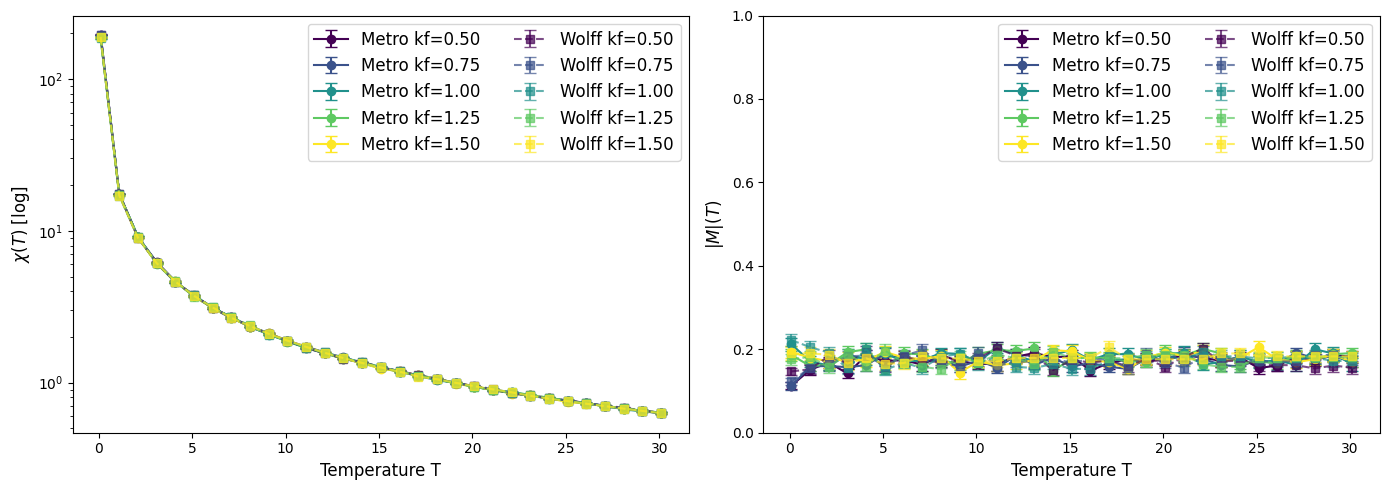

✓ Saved: plots/comparison_metro_vs_wolff.png


In [ ]:
# Load the generated data
with open("data/mag_chi_vs_kf.json", "r") as f:
    data = json.load(f)
plt.style.use('seaborn-v0_8-muted')
T_grid = np.array(data["T_grid"])
kf_values = np.array(data["kf_values"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color palette for different kF values
colors = plt.cm.viridis(np.linspace(0, 1, len(kf_values)))

# Plot 1: Susceptibility vs Temperature
ax = axes[0]
for i, entry in enumerate(data["metropolis"]):
    if entry["doping"] == 0.05:  # Filter by doping
        kf = entry["kf"]
        chi = np.array(entry["chi_mean"])
        chi_err = np.array(entry["chi_err"])
        ax.errorbar(T_grid, chi, yerr=chi_err, label=f"Metro kf={kf:.2f}",
                    marker='o', capsize=4, linestyle='-', linewidth=1.5, color=colors[i])

for i, entry in enumerate(data["wolff"]):
    if entry["doping"] == 0.05:  # Filter by doping
        kf = entry["kf"]
        chi = np.array(entry["chi_mean"])
        chi_err = np.array(entry["chi_err"])
        ax.errorbar(T_grid, chi, yerr=chi_err, label=f"Wolff kf={kf:.2f}",
                    marker='s', capsize=4, linestyle='--', linewidth=1.5, alpha=0.7, color=colors[i])
# ax.set_ylim(0,10)
ax.set_yscale('log')
ax.set_xlabel("Temperature T", fontsize=12)
ax.set_ylabel(r"$\chi(T)$ [log]" , fontsize=12)
ax.legend(fontsize=12, ncol=2, loc='best')
# ax.grid(True, alpha=0.3)

# Plot 2: Magnetization vs Temperature
ax = axes[1]
for i, entry in enumerate(data["metropolis"]):
    if entry["doping"] == 0.05:  # Filter by doping
        kf = entry["kf"]
        mag = np.array(entry["mag_mean"])
        mag_err = np.array(entry["mag_err"])
        ax.errorbar(T_grid, mag, yerr=mag_err, label=f"Metro kf={kf:.2f}",
                    marker='o', capsize=4, linestyle='-', linewidth=1.5, color=colors[i])

for i, entry in enumerate(data["wolff"]):
    if entry["doping"] == 0.05:  # Filter by doping
        kf = entry["kf"]
        mag = np.array(entry["mag_mean"])
        mag_err = np.array(entry["mag_err"])
        ax.errorbar(T_grid, mag, yerr=mag_err, label=f"Wolff kf={kf:.2f}",
                    marker='s', capsize=4, linestyle='--', linewidth=1.5, alpha=0.7, color=colors[i])

ax.set_xlabel("Temperature T", fontsize=12)
ax.set_ylabel(r"$|M|(T)$", fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=12, ncol=2, loc='best')
# ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/comparison_metro_vs_wolff.png", dpi=180, bbox_inches='tight')
plt.show()


print("✓ Saved: plots/comparison_metro_vs_wolff.png")

## 3. Statistical Comparison

Compute agreement between Metropolis and Wolff results.

In [ ]:
# Compare results
print("\n" + "="*70)
print("ALGORITHM COMPARISON (Doping = 50%)")
print("="*70)

for kf_val in kf_values:
    # Find entries for this kF
    metro_entry = [e for e in data["metropolis"] if e["kf"] == kf_val and e["doping"] == 0.05][0]
    wolff_entry = [e for e in data["wolff"] if e["kf"] == kf_val and e["doping"] == 0.05][0]
    
    mag_metro = np.array(metro_entry["mag_mean"])
    mag_wolff = np.array(wolff_entry["mag_mean"])
    chi_metro = np.array(metro_entry["chi_mean"])
    chi_wolff = np.array(wolff_entry["chi_mean"])
    
    # Compute relative difference
    mag_diff = np.mean(np.abs((mag_metro - mag_wolff) / (mag_metro + 1e-6)))
    chi_diff = np.mean(np.abs((chi_metro - chi_wolff) / (chi_metro + 1e-6)))
    
    print(f"\nkF = {kf_val:.2f}:")
    print(f"  Magnetization:   avg diff = {mag_diff*100:.2f}%")
    print(f"  Susceptibility:  avg diff = {chi_diff*100:.2f}%")


ALGORITHM COMPARISON (Doping = 50%)

kF = 0.50:
  Magnetization:   avg diff = 8.40%
  Susceptibility:  avg diff = 0.67%

kF = 0.75:
  Magnetization:   avg diff = 7.03%
  Susceptibility:  avg diff = 0.61%

kF = 1.00:
  Magnetization:   avg diff = 9.55%
  Susceptibility:  avg diff = 0.83%

kF = 1.25:
  Magnetization:   avg diff = 9.22%
  Susceptibility:  avg diff = 0.87%

kF = 1.50:
  Magnetization:   avg diff = 7.50%
  Susceptibility:  avg diff = 0.67%


## 4. Advanced: Multi-Doping Comparison

Generate data for multiple doping concentrations to study dilution effects.

In [ ]:
# Generate data for multiple dopings
kf_values_full = np.array([1.0])  # Focus on single kF
doping_values_full = np.array([0.03, 0.05, 0.07])  # Multiple dopings
T_grid_full =  np.linspace(0.1, 30.1, 31)   # Fewer T points for speed

print("\nGenerating multi-doping comparison...")
data_full = generate_comparison_data(
    kf_values=kf_values_full,
    doping_values=doping_values_full,
    T_grid=T_grid_full,
    rows=15,
    cols=15,
    metro_warmup=4000,
    metro_prod=10000,
    wolff_warmup=800,
    wolff_prod=1500,
    filename="mag_chi_multi_doping.json",
    verbose=False
)

print("✓ Multi-doping data generated")


Generating multi-doping comparison...


NameError: name 'generate_comparison_data' is not defined

NameError: name 'data_full' is not defined

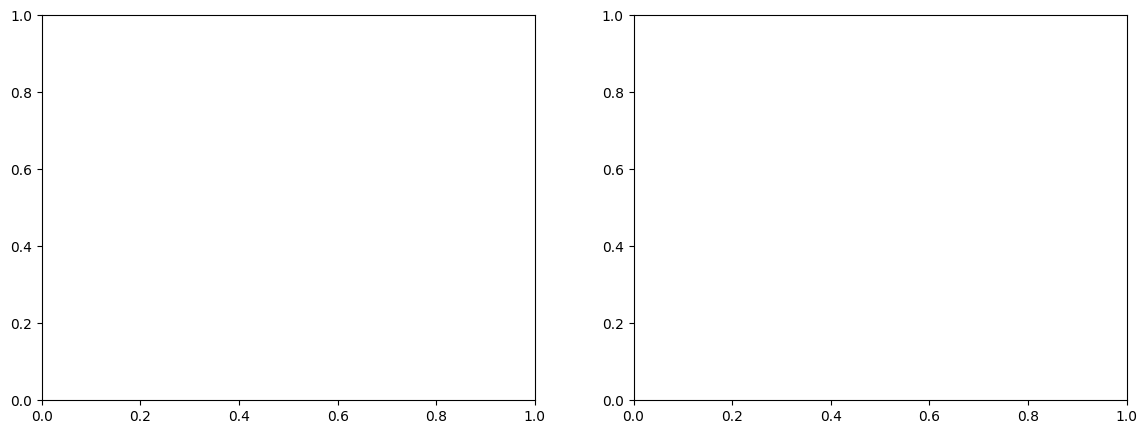

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_doping = plt.cm.coolwarm(np.linspace(0, 1, len(doping_values_full)))

# Susceptibility
ax = axes[0]
for i, doping in enumerate(doping_values_full):
    entry = [e for e in data_full["metropolis"] if e["doping"] == doping][0]
    chi = np.array(entry["chi_mean"])
    chi_err = np.array(entry["chi_err"])
    ax.errorbar(T_grid_full, chi, yerr=chi_err,
                label=f"Metro δ={doping:.1f}", marker='o', capsize=4, 
                linestyle='-', linewidth=1.5, color=colors_doping[i])

for i, doping in enumerate(doping_values_full):
    entry = [e for e in data_full["wolff"] if e["doping"] == doping][0]
    chi = np.array(entry["chi_mean"])
    chi_err = np.array(entry["chi_err"])
    ax.errorbar(T_grid_full, chi, yerr=chi_err,
                label=f"Wolff δ={doping:.1f}", marker='s', capsize=4,
                linestyle='--', linewidth=1.5, alpha=0.7, color=colors_doping[i])

ax.set_xlabel("Temperature T", fontsize=12)
ax.set_ylabel(r"$\chi(T)$", fontsize=12)
ax.set_title("Susceptibility vs Doping (kF=1.0)", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Magnetization
ax = axes[1]
for i, doping in enumerate(doping_values_full):
    entry = [e for e in data_full["metropolis"] if e["doping"] == doping][0]
    mag = np.array(entry["mag_mean"])
    mag_err = np.array(entry["mag_err"])
    ax.errorbar(T_grid_full, mag, yerr=mag_err,
                label=f"Metro δ={doping:.1f}", marker='o', capsize=4,
                linestyle='-', linewidth=1.5, color=colors_doping[i])

for i, doping in enumerate(doping_values_full):
    entry = [e for e in data_full["wolff"] if e["doping"] == doping][0]
    mag = np.array(entry["mag_mean"])
    mag_err = np.array(entry["mag_err"])
    ax.errorbar(T_grid_full, mag, yerr=mag_err,
                label=f"Wolff δ={doping:.1f}", marker='s', capsize=4,
                linestyle='--', linewidth=1.5, alpha=0.7, color=colors_doping[i])

ax.set_xlabel("Temperature T", fontsize=12)
ax.set_ylabel(r"$|M|(T)$", fontsize=12)
ax.set_title("Magnetization vs Doping (kF=1.0)", fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=9, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/comparison_multi_doping.png", dpi=180, bbox_inches='tight')
plt.show()

print("✓ Saved: plots/comparison_multi_doping.png")

In [ ]:
from 